/tmp/ipykernel_11724/288108520.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)
/tmp/ipykernel_11724/288108520.py:40: FutureWarning: 

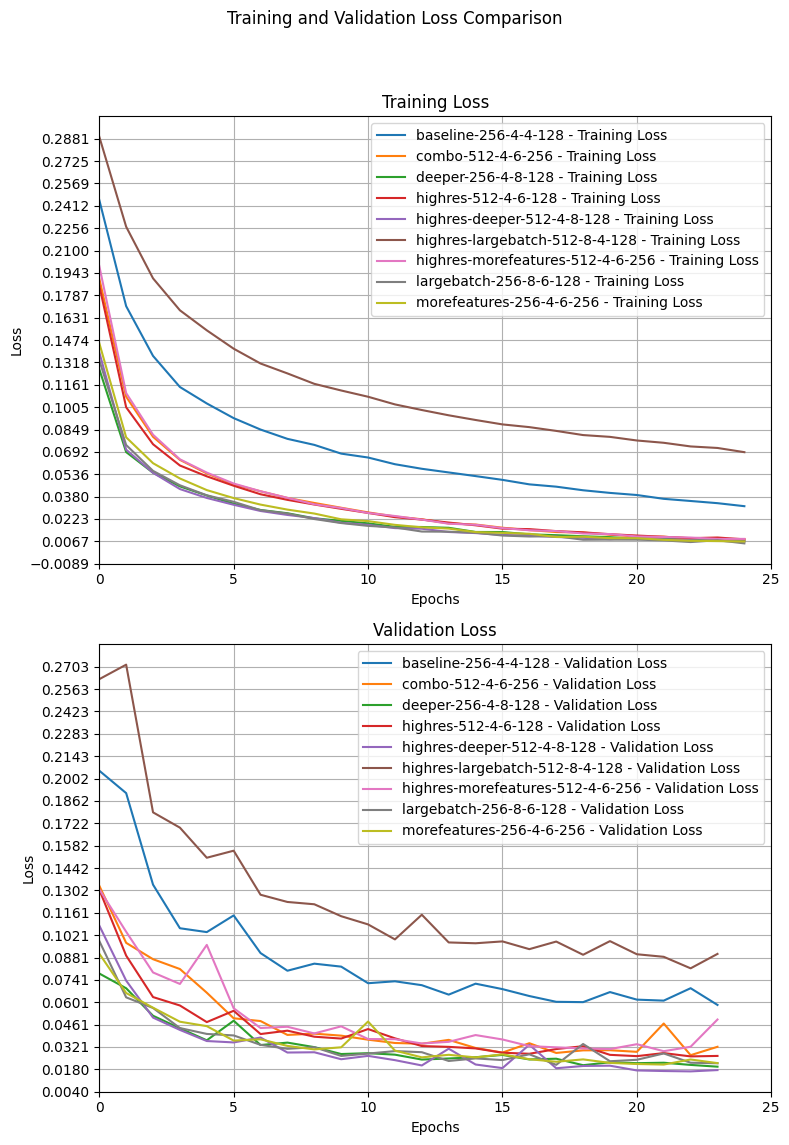

In [9]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
# Path to the folder containing the models
results_folder = 'results'
# List all .pth files in the folder
model_files = [f for f in os.listdir(results_folder) if f.endswith('.pth')]
# Initialize figures for training and validation losses
plt.figure(figsize=(8, 12))  # Adjusted figure size for vertical layout
plt.suptitle('Training and Validation Loss Comparison')
# Plot all training losses
plt.subplot(2, 1, 1)  # Changed to (2, 1, 1) for vertical stacking
for model_file in model_files:
    # Load the model
    model_path = os.path.join(results_folder, model_file)
    checkpoint = torch.load(model_path)
    
    # Extract metadata
    model_config = checkpoint['model_config']
    loss_values = model_config['loss_values']
    model_name = model_config['name']
    
    # Plot training loss
    plt.plot(loss_values, label=f'{model_name} - Training Loss')
# Set y-ticks with increased frequency
plt.xlim(0, 25)
y_min, y_max = plt.ylim()
plt.yticks(np.arange(y_min, y_max, (y_max - y_min) / 20))  # Adjust the divisor for more/less ticks
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
# Plot all validation losses
plt.subplot(2, 1, 2)  # Changed to (2, 1, 2) for vertical stacking
for model_file in model_files:
    # Load the model
    model_path = os.path.join(results_folder, model_file)
    checkpoint = torch.load(model_path)
    
    # Extract metadata
    model_config = checkpoint['model_config']
    val_loss_values = model_config['val_loss_values']
    model_name = model_config['name']
    
    # Plot validation loss
    plt.plot(val_loss_values, label=f'{model_name} - Validation Loss')
# Set y-ticks with increased frequency
y_min, y_max = plt.ylim()
plt.xlim(0, 25)
plt.yticks(np.arange(y_min, y_max, (y_max - y_min) / 20))  # Adjust the divisor for more/less ticks
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)
# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_11724/1710904906.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


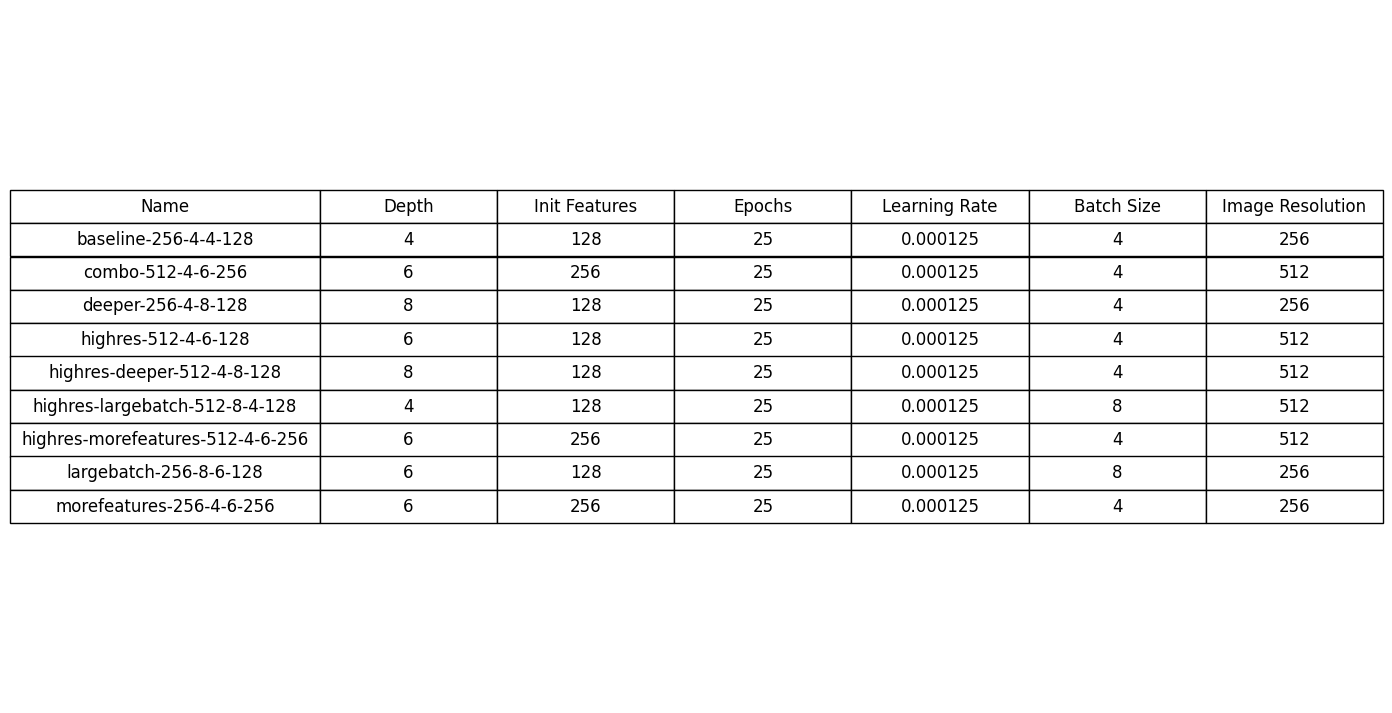

In [10]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
# Path to the folder containing the models
results_folder = 'results'
# List all .pth files in the folder
model_files = [f for f in os.listdir(results_folder) if f.endswith('.pth')]
# Initialize a list to store model data
model_data = []
# Iterate over each model file
for model_file in model_files:
    # Load the model
    model_path = os.path.join(results_folder, model_file)
    checkpoint = torch.load(model_path)
    
    # Extract metadata
    model_config = checkpoint['model_config']
    
    # Append the model data to the list
    model_data.append({
        'Name': model_config['name'],
        'Depth': model_config['depth'],
        'Init Features': model_config['init_features'],
        'Epochs': model_config['epochs'],
        'Learning Rate': model_config['learning_rate'],
        'Batch Size': model_config['batch_size'],
        'Image Resolution': model_config['image_resolution'],
    })
# Create a DataFrame from the model data
df = pd.DataFrame(model_data)
# Plot the DataFrame as a table
fig, ax = plt.subplots(figsize=(8, len(df) * 1))  # Adjust height based on number of models
ax.axis('tight')
ax.axis('off')
# Create the table with larger font size
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
# Increase font size
table.auto_set_font_size(False)
table.set_fontsize(12)  # Set the desired font size
# Scale the table for better readability
table.scale(2, 2)
# Adjust the width of the first column
for (i, j), cell in table.get_celld().items():
    if j == 0:  # First column
        cell.set_width(0.5)  # Set the desired width
# Show the plot
plt.show()